In [2]:
# Run once if needed
pip install -r requirements.txt


SyntaxError: invalid syntax (331094951.py, line 2)

In [ ]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage


: 

In [28]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [29]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [30]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    final: str

In [31]:
llm = ChatOpenAI(model="gpt-4.1-mini")

OpenAIError: Missing credentials. Please pass an `api_key`, `workload_identity`, `admin_api_key`, or set the `OPENAI_API_KEY` or `OPENAI_ADMIN_KEY` environment variable.

In [19]:
def orchestrator(state: State) -> dict:
    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ), 
            HumanMessage(content=f"Topic: {state['topic']} ")

        ]
    )

    return {"plan": plan}

In [20]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks
            ]

In [21]:
def worker(payload: dict) -> dict:

    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title
    
    section_md = llm.invoke(
        [
        SystemMessage(content="Write one clean Markdown section."),
        HumanMessage(content =(
            f"Blog: {blog_title}\n",
            f"Topic: {topic}\n\n"
            f"Section: {task.title}\n"
            f"Brief: {task.brief}\n\n"
            "Return only the section content in Markdown."
                )   
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}


In [22]:
from pathlib import Path

def reducer(state: State) -> dict:
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# (title)\n\n{body}\n"

    # ---------  save to file -------------
    filename = title.lower().replace(" ", "_") + ". md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf=8")

    return { "final": final_md}

In [23]:

g =  StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

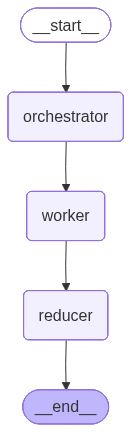

In [24]:
g.add_edge(START, "orchestrator")
g.add_edge("orchestrator", "worker")
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [ ]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})